# Practical 1 — Visual Wildlife Datasets

Before building any model, you need to understand the data. Wildlife
imagery comes from two main platforms — **camera traps** (ground-level)
and **drones** (aerial) — and each platform uses different annotation
formats to label what is in the images.

This practical walks through **four annotation types**, from simplest to
most detailed, showing real examples from public datasets at each level:

1. **Image Level classification** — one label per photo
2. **Bounding boxes** — a rectangle around each animal
3. **Point annotations** — a single (x, y) coordinate per animal
4. **Segmentation masks** — pixel-level outlines (preview for Practical 7)

Each type trades off **annotation effort** against **spatial detail**.
By the end you will know which format each tool uses (MegaDetector → boxes,
HerdNet → points, SAM → masks) and when each is the right choice.

In [1]:
from pathlib import Path

DATA_BASE = Path.cwd().parent / "data"
print(f"DATA_BASE: {DATA_BASE}")

DATA_BASE: /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data


---

## 1. Image Classification

The simplest annotation type: **one label per image**. The entire photo
is tagged with a species name — no information about where the animal is
in the frame.

This is the format used by camera trap management platforms (Wildlife
Insights, Agouti, Trapper) and by species classifiers downstream of
MegaDetector.

**Snapshot Serengeti** — 7.1 million camera trap images from Tanzania,
40+ mammalian species, stored as COCO JSON with three top-level lists
(`images`, `annotations`, `categories`) linked by ID fields.

In [2]:
from wildlife_detection.download_data import download_serengeti
download_serengeti(n_images=50, output_dir=DATA_BASE)

Serengeti already downloaded (50 images in /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/camera_trap/serengeti_subset)


/Users/christian/opt/anaconda3/envs/fit-megadetector/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/camera_trap/serengeti_subset')

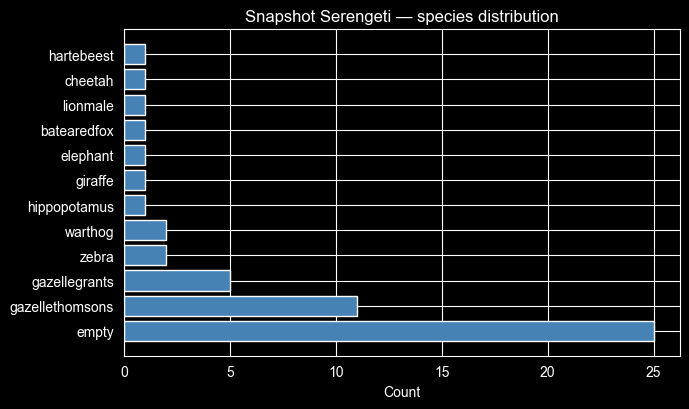

In [3]:
from wildlife_detection.download_data import show_class_distribution
show_class_distribution("serengeti", output_dir=DATA_BASE)

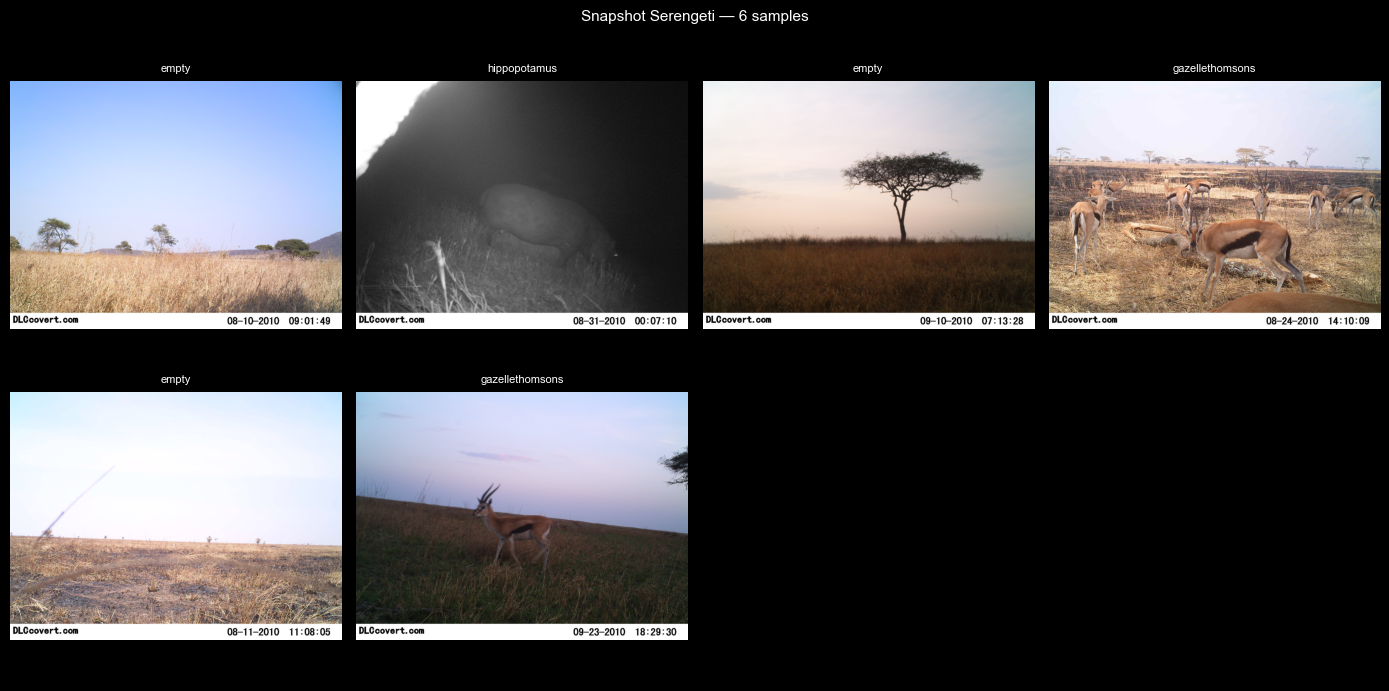

In [4]:
from wildlife_detection.download_data import show_samples
show_samples("serengeti", n=6, output_dir=DATA_BASE)

---

## 2. Bounding Boxes

A bounding box adds **spatial information**: a rectangle around each animal
tells you not just *what* is there, but *where* it is. This is the format
used by most object detectors: **MegaDetector**, **YOLOv8**, **Faster R-CNN**.

Three common bounding box formats exist — you will convert between them
in Practical 3:

| Format | Coordinates | Used by |
|--------|-------------|---------|
| **COCO** | `[x, y, w, h]` — top-left + size, pixels | COCO JSON, MegaDetector |
| **YOLO** | `[cx, cy, w, h]` — centre + size, normalised 0–1 | Ultralytics, training |
| **Pascal VOC** | `[x_min, y_min, x_max, y_max]` — corners, pixels | VOC XML |

**Caltech Camera Traps** — camera trap images with bounding box annotations
around each detected animal.

In [5]:
from wildlife_detection.download_data import download_caltech
download_caltech(n_images=50, output_dir=DATA_BASE)


=== Caltech Camera Traps (n=50) ===
  243100 total images in metadata
  Sampled 50 images across species: ['badger', 'bat', 'bird', 'bobcat', 'car', 'cat', 'cow', 'coyote', 'deer', 'dog', 'empty', 'fox', 'insect', 'lizard', 'mountain_lion', 'opossum', 'pig', 'rabbit', 'raccoon', 'rodent', 'skunk', 'squirrel']
  61945 bbox annotations loaded
  Reference labels → /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/camera_trap_labels.csv


Caltech images: 100%|██████████| 50/50 [00:00<00:00, 31249.47it/s]

  Done. Images in /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/camera_trap/caltech_subset


PosixPath('/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/camera_trap/caltech_subset')

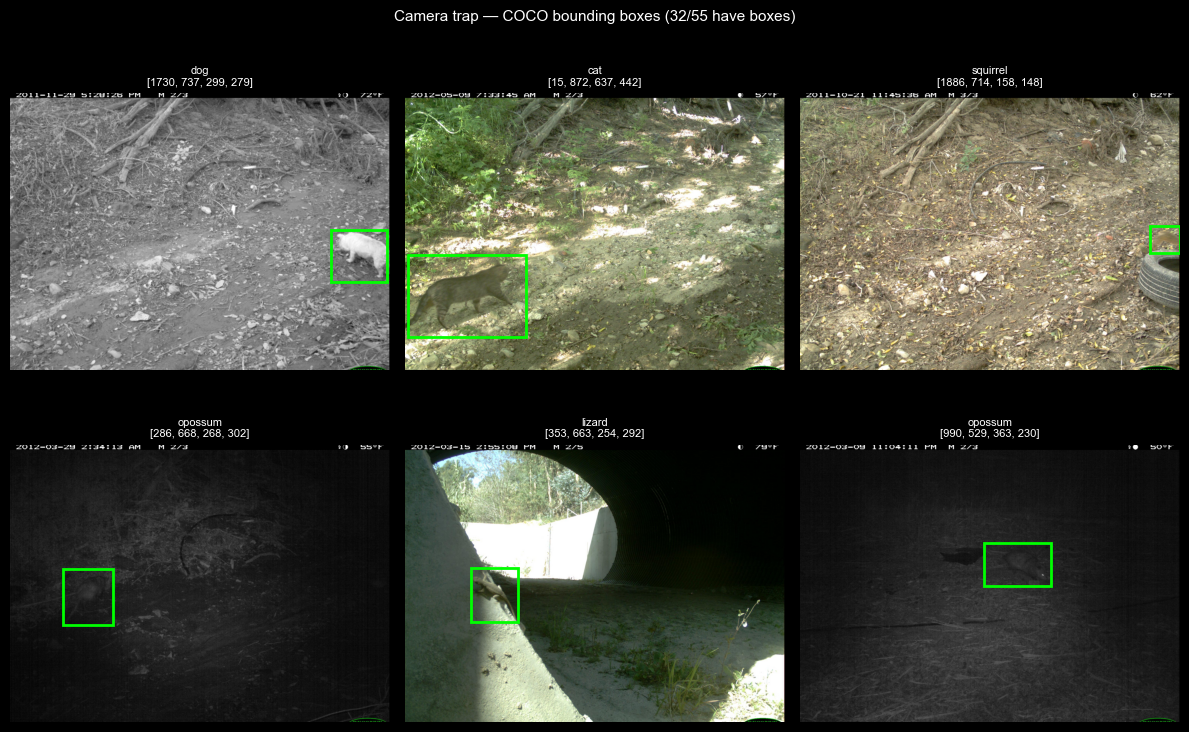

In [6]:
from wildlife_detection.download_data import show_bboxes
show_bboxes("caltech", n=6, output_dir=DATA_BASE)

---

## 3. Point Annotations

A point annotation is the **lightest spatial label**: a single `(x, y)`
coordinate marking the centre of each animal. No box dimensions needed.

This dramatically reduces annotation effort — especially for **dense
colonies** where drawing tight boxes around overlapping animals is
impractical. It is the format used by **HerdNet** (Delplanque et al., 2023)
and the **Iguanas From Above** project throughout this course.

The HerdNet General Dataset stores annotations as a CSV:

| Column | Meaning |
|--------|---------|
| `images` | Tile filename |
| `x`, `y` | Pixel coordinate within the tile |
| `labels` | Species class |

**One row = one animal.** Tiles with no animals have no rows in the CSV.

In [7]:
from wildlife_detection.download_data import download_general_dataset
download_general_dataset(n_images=50, output_dir=DATA_BASE)


=== karisu/General_Dataset (n=50) ===
  Downloaded 50/1304 images
  Saved to /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/general_dataset


PosixPath('/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/general_dataset')

'\nThe annotations are structured here as follows:\nimages,x,y,labels\nExample.JPG,517,1653,2\nExample.JPG,800,1253,1\nExample.JPG,78,33,3\nExample_2.JPG,896,742,1\n\n# the six classes reflect: Buffalo, elephant, kob, topi, warthog, waterbuck\n\n\n'

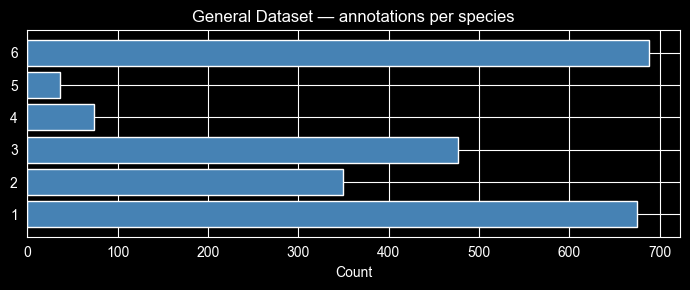

In [8]:
from wildlife_detection.download_data import show_class_distribution
show_class_distribution("general_dataset", output_dir=DATA_BASE)

"""
The annotations are structured here as follows:
images,x,y,labels
Example.JPG,517,1653,2
Example.JPG,800,1253,1
Example.JPG,78,33,3
Example_2.JPG,896,742,1

# the six classes reflect: Buffalo, elephant, kob, topi, warthog, waterbuck


"""

Tiles: 50  |  Annotations: 2299  |  Annotated tiles: 258  |  Median per tile: 3  |  Max: 144


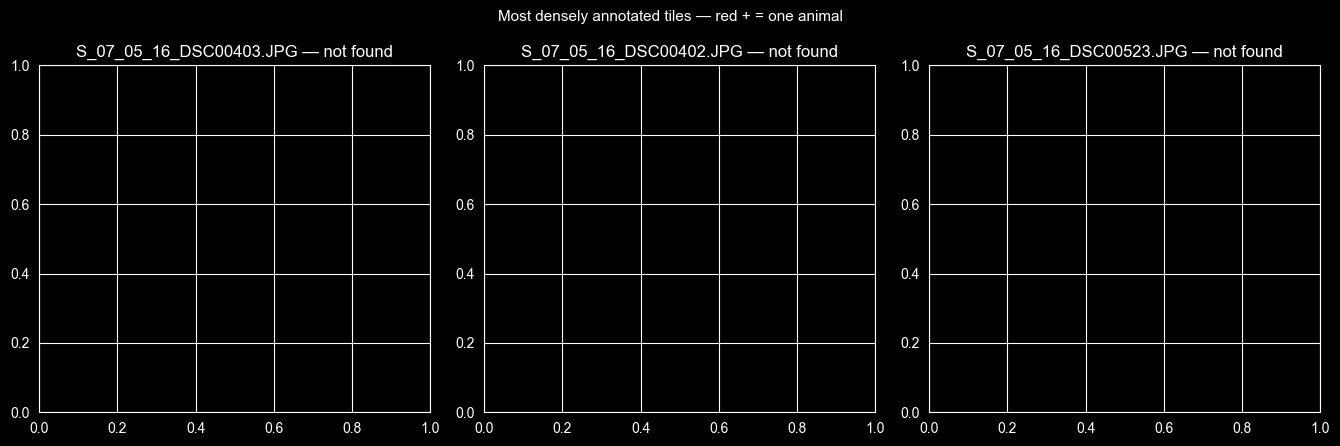

In [9]:
from wildlife_detection.download_data import show_annotated_tiles
show_annotated_tiles(n=3, output_dir=DATA_BASE)

---

### Aerial Bounding Boxes — Eikelboom 2019

The same bounding box format works for **aerial imagery** too. The
Eikelboom 2019 dataset contains nadir drone images of African savanna
megafauna with YOLO-format bounding boxes.

Compare these to the Caltech camera trap boxes above — aerial animals
are much smaller relative to the image, viewed from above, and often
appear in groups.

In [ ]:
from wildlife_detection.download_data import download_eikelboom
download_eikelboom(n_images=10, output_dir=DATA_BASE)


=== Eikelboom 2019 (n=10 per split) ===


In [ ]:
from wildlife_detection.download_data import show_bboxes
show_bboxes("eikelboom", n=6, output_dir=DATA_BASE)

In [ ]:
show_class_distribution("eikelboom", output_dir=DATA_BASE)

---

### From Full Images to Training Tiles

Aerial and drone images are often much larger than what a neural network
can process at once (e.g. 4000x3000 px). The standard approach is to cut
them into smaller **tiles** (typically 512x512 px) with overlapping edges,
and project the annotations into each tile's local coordinate system.

This tiling step is critical for training — the model never sees the full
image, only tiles. Let's see how it works on both datasets.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

from wildlife_detection.tiling.utils import generate_tile_windows, read_tile

# Pick an Eikelboom image with annotations
import pandas as pd
eik_dir = DATA_BASE / "eikelboom"
ann_df = pd.read_csv(eik_dir / "annotations" / "annotations_images.csv")

# Find an image with several annotations
box_counts = ann_df["FILE"].value_counts()
example_file = box_counts.index[0]  # most annotated image

# Find the image on disk
for split in ["train", "test", "val"]:
    img_path = eik_dir / split / example_file
    if img_path.exists():
        break

img = np.array(Image.open(img_path))
h, w = img.shape[:2]
file_anns = ann_df[ann_df["FILE"] == example_file]

print(f"Image: {example_file} ({w}x{h} px, {len(file_anns)} annotations)")

# Generate tiles
TILE_SIZE = 512
OVERLAP = 120
windows = list(generate_tile_windows(w, h, TILE_SIZE, OVERLAP))
print(f"Tiles: {len(windows)} tiles of {TILE_SIZE}x{TILE_SIZE} px with {OVERLAP} px overlap")

# Show the full image with tile grid and annotations
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(img)

# Draw tile grid
for win in windows:
    rect = mpatches.Rectangle(
        (win.col_off, win.row_off), win.width, win.height,
        linewidth=0.5, edgecolor="cyan", facecolor="none", linestyle="--", alpha=0.5
    )
    ax.add_patch(rect)

# Draw annotations
for _, row in file_anns.iterrows():
    x1, y1, x2, y2 = row["x1"], row["y1"], row["x2"], row["y2"]
    rect = mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="lime", facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 2, row["SPECIES"], fontsize=6, color="lime", backgroundcolor="black")

ax.set_title(f"{example_file} — {len(windows)} tiles (cyan) + {len(file_anns)} annotations (green)", fontsize=10)
ax.axis("off")
plt.tight_layout()

In [ ]:
# Show individual tiles with their local annotations
tiles_with_anns = []
for win in windows:
    tile = read_tile(img, win, TILE_SIZE)
    # Find annotations that fall inside this tile
    local_anns = []
    for _, row in file_anns.iterrows():
        x1, y1, x2, y2 = row["x1"], row["y1"], row["x2"], row["y2"]
        # Check if box overlaps with tile
        if x2 > win.col_off and x1 < win.col_off + win.width and \
           y2 > win.row_off and y1 < win.row_off + win.height:
            # Convert to local tile coordinates
            lx1 = max(0, x1 - win.col_off)
            ly1 = max(0, y1 - win.row_off)
            lx2 = min(win.width, x2 - win.col_off)
            ly2 = min(win.height, y2 - win.row_off)
            local_anns.append((lx1, ly1, lx2, ly2, row["SPECIES"]))
    if local_anns:
        tiles_with_anns.append((tile, win, local_anns))

# Show up to 6 tiles that contain annotations
n_show = min(6, len(tiles_with_anns))
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off"); continue
    tile, win, local_anns = tiles_with_anns[i]
    ax.imshow(tile)
    for lx1, ly1, lx2, ly2, species in local_anns:
        rect = mpatches.Rectangle(
            (lx1, ly1), lx2 - lx1, ly2 - ly1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(lx1, ly1 - 2, species, fontsize=6, color="lime", backgroundcolor="black")
    ax.set_title(f"Tile ({win.col_off}, {win.row_off}) — {len(local_anns)} boxes", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Eikelboom tiles ({TILE_SIZE}x{TILE_SIZE}) with projected bounding boxes", fontsize=11)
plt.tight_layout()

In [ ]:
# Same for General Dataset — tiling with point annotations
gd_dir = DATA_BASE / "general_dataset"

# Find the CSV and image dir that exist
for csv_name, img_subdir in [("test.csv", "test"), ("test_sample.csv", "test_sample")]:
    gd_csv = gd_dir / csv_name
    gd_img_dir = gd_dir / img_subdir
    if gd_csv.exists() and gd_img_dir.exists():
        break

gd_df = pd.read_csv(gd_csv)

# Only keep annotations for images that are actually on disk
existing_imgs = {p.name for p in gd_img_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
gd_df = gd_df[gd_df["images"].isin(existing_imgs)]

# Pick the most annotated image that exists
gd_counts = gd_df.groupby("images").size().sort_values(ascending=False)
gd_example = gd_counts.index[0]
gd_img_path = gd_img_dir / gd_example

gd_img = np.array(Image.open(gd_img_path))
gh, gw = gd_img.shape[:2]
gd_file_anns = gd_df[gd_df["images"] == gd_example]

print(f"Image: {gd_example} ({gw}x{gh} px, {len(gd_file_anns)} point annotations)")

gd_windows = list(generate_tile_windows(gw, gh, TILE_SIZE, OVERLAP))
print(f"Tiles: {len(gd_windows)} tiles of {TILE_SIZE}x{TILE_SIZE} px")

# Show full image with tile grid and points
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(gd_img)

for win in gd_windows:
    rect = mpatches.Rectangle(
        (win.col_off, win.row_off), win.width, win.height,
        linewidth=0.5, edgecolor="cyan", facecolor="none", linestyle="--", alpha=0.5
    )
    ax.add_patch(rect)

ax.scatter(gd_file_anns["x"], gd_file_anns["y"], c="red", s=40,
           edgecolors="white", linewidths=0.5, zorder=5)

ax.set_title(f"{gd_example} — {len(gd_windows)} tiles (cyan) + {len(gd_file_anns)} points (red)", fontsize=10)
ax.axis("off")
plt.tight_layout()

In [ ]:
# Show individual tiles with projected point annotations
gd_tiles_with_pts = []
for win in gd_windows:
    tile = read_tile(gd_img, win, TILE_SIZE)
    local_pts = []
    for _, row in gd_file_anns.iterrows():
        px, py = row["x"], row["y"]
        if win.col_off <= px < win.col_off + win.width and \
           win.row_off <= py < win.row_off + win.height:
            local_pts.append((px - win.col_off, py - win.row_off, row["labels"]))
    if local_pts:
        gd_tiles_with_pts.append((tile, win, local_pts))

n_show = min(6, len(gd_tiles_with_pts))
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off"); continue
    tile, win, local_pts = gd_tiles_with_pts[i]
    ax.imshow(tile)
    xs = [p[0] for p in local_pts]
    ys = [p[1] for p in local_pts]
    ax.scatter(xs, ys, c="red", s=60, edgecolors="white", linewidths=1, zorder=5)
    ax.set_title(f"Tile ({win.col_off}, {win.row_off}) — {len(local_pts)} points", fontsize=8)
    ax.axis("off")

plt.suptitle(f"General Dataset tiles ({TILE_SIZE}x{TILE_SIZE}) with projected point annotations", fontsize=11)
plt.tight_layout()

---

## 4. Segmentation Masks (Preview)

The fourth and most detailed annotation type: **every pixel** is assigned
a class label. This is the most expensive to annotate but gives precise
outlines. You will work with this in **Practical 7** using Segment
Anything (SAM).

**When is segmentation useful in ecology?**
- Habitat mapping (land cover from satellite/drone imagery)
- Canopy delineation (individual tree crowns)
- Precise area estimation (coral coverage, burn scars)
- Instance segmentation when animals overlap heavily


One example Dataset for Tree Crowns: https://www.dlr.de/en/eoc/about-us/remote-sensing-technology-institute/photogrammetry-and-image-analysis/public-datasets/bamforests
![image-1385-89dd238ac1b67d99db3e95162cd3d431.jpeg](assets/image-1385-89dd238ac1b67d99db3e95162cd3d431.jpeg)


---

## Summary — Annotation Types at a Glance

| Type | Spatial detail | Annotation effort | Example tools | Best for |
|------|---------------|-------------------|---------------|----------|
| **Image label** | None | Lowest | DeepFaune, SpeciesNet | Species ID after detection |
| **Bounding box** | Rectangle | Medium | MegaDetector, YOLOv8 | Counting, localisation |
| **Point** | Centre (x, y) | Low | HerdNet | Dense colonies, aerial |
| **Segmentation mask** | Pixel outline | Highest | SAM, U-Net | Habitat mapping, area |

More spatial detail is **not always better** — the right choice depends
on your ecological question and how much annotation time you can afford.

## Exercise

1. Compare a camera trap image with an aerial tile side by side.
   List three visual differences that would affect a detection model.
2. The Serengeti dataset uses bounding boxes; HerdNet uses points.
   Which annotation type would you choose for iguanas from the air, which would you choose for camera traps, and why?
3. Look at the Eikelboom aerial images. How do the animals compare in
   size and visibility to the HerdNet tiles?
4. Point annotations are stored as pixel coordinates. What extra
   information would you need to convert them to GPS positions?

## Reflection

- Camera traps and drones produce very different data. How should this
  affect your choice of detection model?
- Empty tiles have no rows in the CSV. What does this mean for training
  a model that must also learn to say "nothing here"?
- The four annotation types form a hierarchy of increasing spatial detail.
  Is more detail always better, or is there a cost?